In [3]:
from __future__ import annotations

import sys
from pathlib import Path
from tqdm import trange
import numpy as np
ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'hidden_sector_DM').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from hidden_sector_DM.HiddenSectorDM import VectorPortal, BaryonPortal, HiggsPortal       # noqa: E402

from GCE import FIGS_DIR                                       # noqa: E402
from GCE.likelihood import cascade_template,direct_template, gls_fit, measurement   # noqa: E402
from GCE.pythia_runner import DEFAULT_SEED                     # noqa: E402
from scipy.ndimage import shift as ndimage_shift
from GCE.halo import HALO_2112, RHO_LOCAL_PRIOR
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
from matplotlib.tri import Triangulation, LinearTriInterpolator
from scipy.ndimage import gaussian_filter, gaussian_filter1d
plt.style.use(ROOT / 'notebooks' / 'mine.mplstyle')
plt.rcParams['axes.axisbelow'] = False

In [7]:
# ---- configuration -------------------------------------------------------
M_LIM = (15.0, 80.0)          # DM mass range [GeV]
N_MASS = 50                    # log-spaced points across M_LIM
DECIMALS = 2                   # rounding; the consumer must ask for the same masses

MX_GRID = np.round(np.logspace(*np.log10(M_LIM), N_MASS), DECIMALS)
REGION = "south"        # 'both' (40x40), 'south' or 'north'
N_EVENTS = 200_000      # what the channel_spectra cache holds
SEED = DEFAULT_SEED

# ---- the fit -------------------------------------------------------------
phi, Cinv = measurement(region=REGION)      # once; independent of the model

n_pts = len(MX_GRID)
chi2 = np.full(n_pts, np.nan)
ts = np.full((n_pts, 14), np.nan)
sigmav = np.full(n_pts, np.nan)
sigmav_err = np.full(n_pts, np.nan)

for k in trange(n_pts):
    mX = MX_GRID[k]
    t=direct_template(mX, n_events=N_EVENTS, seed=SEED)
    ts[k] = t
    sigmav[k], sigmav_err[k], chi2[k] = gls_fit(t, phi, Cinv)

k_best = int(np.nanargmin(chi2))
print(f"\nbest fit: mX={MX_GRID[k_best]:g}, "
      f"chi2={chi2[k_best]:.2f} / {14 - 2} dof")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 428.15it/s]


best fit: mX=40.4, chi2=19.42 / 12 dof


In [21]:
# ============================================================================
# (mX, <sigma v>) region with the local DM density uncertainty folded into the
# chi2, so the contour inflates smoothly instead of being widened by hand into a
# flat-topped band.  Self-contained: rebuilds the fixed-halo surface on its own
# (wide) <sigma v> axis, then profiles rho_local out of it.
# ============================================================================
sigmav_axis = np.logspace(-27, -24, 700)
sigmav_log_step = np.diff(np.log(sigmav_axis))[0]
mx_columns = np.unique(MX_GRID)
chi2_fixed_halo = np.full((sigmav_axis.size, mx_columns.size), np.nan)
for j in trange(len(mx_columns)):
    mx=mx_columns[j]
    in_column = ((MX_GRID == mx) & np.isfinite(chi2)
                 & np.isfinite(sigmav) & np.isfinite(sigmav_err))
    if not in_column.any():
        continue
    sv_hat, sv_err, chi2_min = (sigmav[in_column], sigmav_err[in_column],
                                chi2[in_column])
    parabola = chi2_min + ((sigmav_axis[:, None] - sv_hat) / sv_err) ** 2
    chi2_fixed_halo[:, j] = parabola.min(axis=1)

# rho_local prior -> chi2 penalty on the log Jbar rescaling.
rho_mean, rho_sigma = RHO_LOCAL_PRIOR # (0.44, 0.13) GeV/cm^3
rho_lognormal_width = rho_sigma / rho_mean
rho_samples = rho_mean * np.exp(np.linspace(-4, 4, 201) * rho_lognormal_width)
ln_jbar_offset = 2.0 * np.log(rho_samples / HALO_2112["rho_local"])          # u
halo_penalty = (np.log(rho_samples / rho_mean) / rho_lognormal_width) ** 2   # P(u)
chi2_marginalised = np.full_like(chi2_fixed_halo, np.inf)
for u, penalty in zip(ln_jbar_offset, halo_penalty):
    shifted = ndimage_shift(chi2_fixed_halo, (-u / sigmav_log_step, 0),
                            order=1, cval=np.inf, mode="constant")
    np.minimum(chi2_marginalised, shifted + penalty, out=chi2_marginalised)

dchi2_fixed_halo = chi2_fixed_halo - np.nanmin(chi2_fixed_halo)
dchi2_marginalised = chi2_marginalised - np.nanmin(chi2_marginalised)
dchi2_fixed_halo_smooth   = gaussian_filter1d(dchi2_fixed_halo,  1, axis=1, mode="nearest")
dchi2_marginalised_smooth = gaussian_filter1d(dchi2_marginalised, 1, axis=1, mode="nearest")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 25004.79it/s]


In [22]:
def color_shades(color, n, lightest_alpha=0.25):
    """Generate n shades from `color` to lighter, blended toward white.

    Parameters
    ----------
    color : str or RGB tuple
        Base color (e.g. "tab:blue").
    n : int
        Number of shades.
    lightest_alpha : float
        Fraction of base color in the lightest shade (0=white, 1=original).

    Returns
    -------
    list of hex color strings, from darkest to lightest.
    """
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    fracs = np.linspace(1.0, lightest_alpha, n)
    return [mcolors.to_hex(rgb * f + white * (1 - f)) for f in fracs]

In [27]:
import re
import numpy as np

def read_contours(path):
    """{68: (N,2), 95: (N,2)} arrays of (mDM, <sv>), each closed."""
    out, key = {}, None
    for line in open(path):
        if m := re.match(r"\s*#\s*(\d+)\s*%", line):
            key = int(m.group(1)); out[key] = []
        elif not line.lstrip().startswith("#") and line.strip():
            out[key].append(line.split())
    return {k: np.array(v + v[:1], float) for k, v in out.items()}
    
sigmav_mX_contour_2112=read_contours("../data/contours_2112.09706/DM_to_bb_contour_GCE_south.txt")

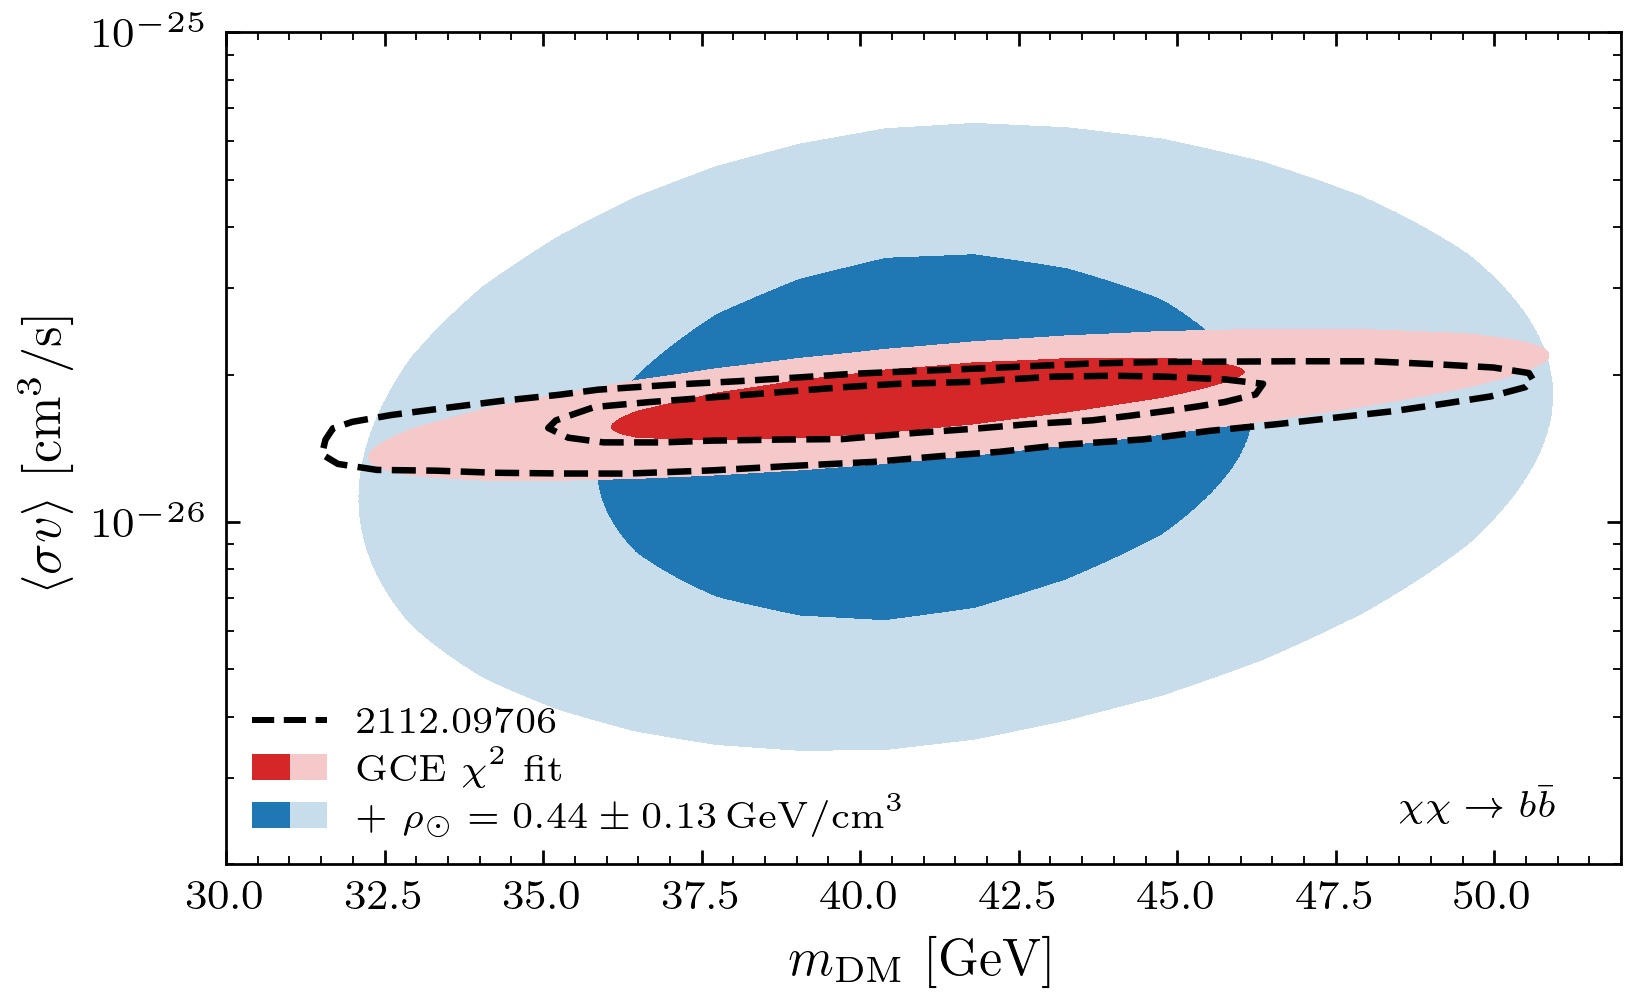

In [31]:

css=[color_shades('k', 2),color_shades('tab:red', 2),color_shades('tab:blue', 2)]
label_names=['2112.09706', 'GCE $\chi^2$ fit', r' + $\rho_{\odot}=0.44\pm 0.13\,{\rm GeV}/{\rm cm}^3$']
fig = plt.figure(figsize=(5, 3))
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax1= fig.add_subplot(gs[:, :])
ax1.set_xlim(30,52)
ax1.contourf(mx_columns, sigmav_axis, dchi2_marginalised_smooth, levels=[0,2.30, 6.18],
           colors=[css[2][0], css[2][1]], alpha=1)
ax1.contourf(mx_columns, sigmav_axis, dchi2_fixed_halo_smooth, levels=[0,2.30, 6.18],
           colors=[css[1][0], css[1][1]], alpha=1)
ax1.plot(sigmav_mX_contour_2112[95][:,0],sigmav_mX_contour_2112[95][:,1]*1e-26,color=css[0][0],ls='--')
ax1.plot(sigmav_mX_contour_2112[68][:,0],sigmav_mX_contour_2112[68][:,1]*1e-26,color=css[0][0],ls='--')
ax1.set_xlabel(r"$m_{\rm DM}\,\,[{\rm GeV}]$")
ax1.set_ylabel(r"$\langle \sigma v\rangle\,\,[{\rm cm}^3/{\rm s}]$")
ax1.set_yscale("log")
ax1.set_ylim(2e-27,1e-25)
ax1.text(51,2.5e-27,r'$\chi\chi\rightarrow b\bar b$', fontsize=mpl.rcParams['legend.fontsize'], ha='right')

handles,labels=[],[]
for i in range(3):
    if i==0:
        labels  += [label_names[i]]
        handles += [ Line2D(
    [0], [0], 
    color='black', 
    linestyle='--', 
    linewidth=1.2)]   
    else:
        patch95 = Patch(facecolor=css[i][1])
        patch68 = Patch(facecolor=css[i][0])
        labels  += [label_names[i]]
        handles += [(patch68, patch95)]
ax1.legend(
    handles=handles,
    labels=labels,
    loc=3,
    fontsize=mpl.rcParams['legend.fontsize'],
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.savefig("../figs/GCE_fit_chichi_bb_validation.png")
#plt.savefig("figs/GCE_fit_chichi_bb_validation.pdf")
plt.show()
plt.close()